# Modeling Stroop Interference in the Clarion Cognitive Architecture

**COG260 Final Project**

This notebook runs and visualizes the Stroop task simulation built on
Clarion's two-level architecture using pyClarion.

**Architecture overview:**
- **Bottom level** (implicit): Automatic feature-to-response activation via weighted connections
- **Top level** (explicit): Goal-directed production rules that always select the correct response
- **ACS integration**: Weighted sum of both levels, followed by Boltzmann action selection

**Predictions:**
1. Congruent trials → high accuracy, low response conflict
2. Neutral trials → intermediate performance (baseline)
3. Incongruent trials → lower accuracy, higher response conflict
4. Increasing cognitive control (W_top) reduces the Stroop effect

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import from our modules
from bottom_level import get_bottom_activations, COLORS, RESPONSES
from top_level import get_top_activations
from simulations import (
    integrate_activations, boltzmann_select,
    run_single_trial, run_experiment, summarize_results,
    plot_accuracy, plot_conflict, plot_parameter_effect
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Single Trial Walkthrough

Before running the full experiment, we trace one trial of each type through
the complete processing pipeline to show how the architecture works.

In [3]:
# Walk through one trial of each type with ink=blue
trial_types = {
    "Congruent (word=BLUE, ink=blue)": ("blue", "blue"),
    "Incongruent (word=RED, ink=blue)": ("blue", "red"),
    "Neutral (word=XXX, ink=blue)": ("blue", "neutral"),
}

for label, (ink, word) in trial_types.items():
    print(f"=== {label} ===")
    
    bottom = get_bottom_activations(ink, word)
    top = get_top_activations(ink)
    combined = integrate_activations(bottom, top, w_bottom=1.0, w_top=0.3)
    
    print(f"  Bottom level:  {', '.join(f'{k}={v:.3f}' for k, v in bottom.items())}")
    print(f"  Top level:     {', '.join(f'{k}={v:.3f}' for k, v in top.items())}")
    print(f"  Combined:      {', '.join(f'{k}={v:.3f}' for k, v in combined.items())}")
    
    sorted_acts = sorted(combined.values(), reverse=True)
    gap = sorted_acts[0] - sorted_acts[1]
    print(f"  Activation gap: {gap:.3f}  |  Conflict (1/gap): {1/gap:.2f}")
    print()

=== Congruent (word=BLUE, ink=blue) ===
  Bottom level:  say_red=0.000, say_blue=0.678, say_green=0.000
  Top level:     say_red=0.000, say_blue=1.000, say_green=0.000
  Combined:      say_red=0.000, say_blue=0.978, say_green=0.000
  Activation gap: 0.978  |  Conflict (1/gap): 1.02

=== Incongruent (word=RED, ink=blue) ===
  Bottom level:  say_red=0.424, say_blue=0.254, say_green=0.000
  Top level:     say_red=0.000, say_blue=1.000, say_green=0.000
  Combined:      say_red=0.424, say_blue=0.554, say_green=0.000
  Activation gap: 0.131  |  Conflict (1/gap): 7.66

=== Neutral (word=XXX, ink=blue) ===
  Bottom level:  say_red=0.000, say_blue=0.254, say_green=0.000
  Top level:     say_red=0.000, say_blue=1.000, say_green=0.000
  Combined:      say_red=0.000, say_blue=0.554, say_green=0.000
  Activation gap: 0.554  |  Conflict (1/gap): 1.80



### Activation Comparison Across Trial Types

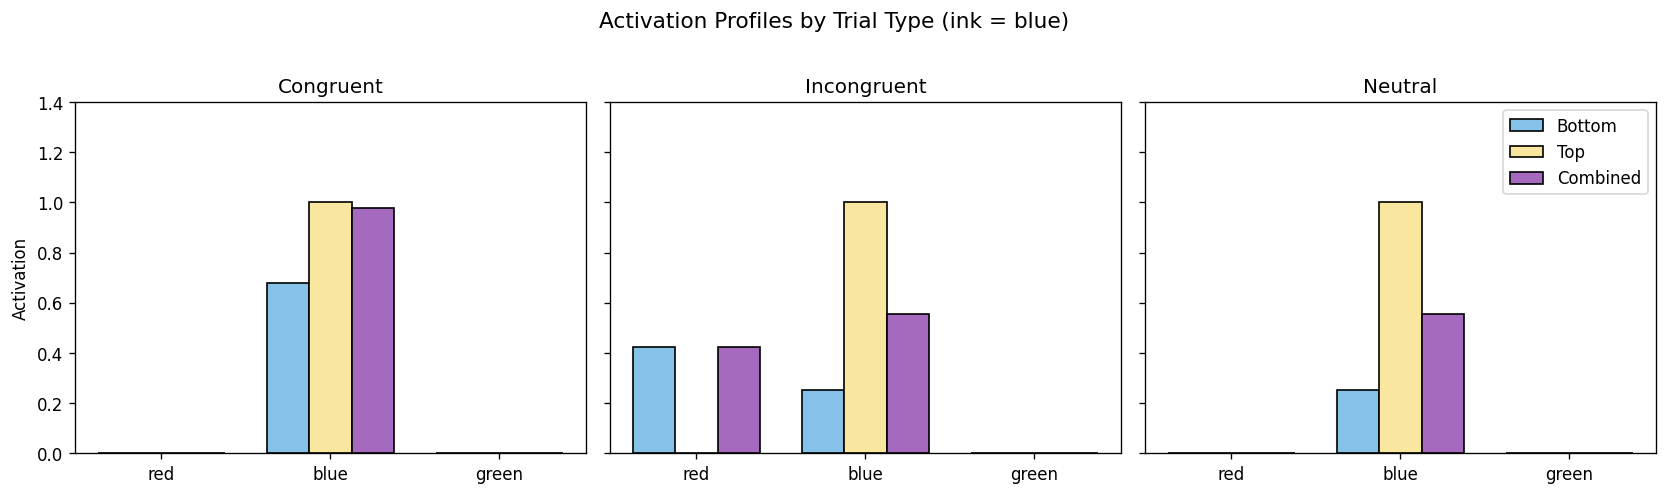

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

bar_colors = {"say_red": "#e74c3c", "say_blue": "#3498db", "say_green": "#2ecc71"}

for ax, (label, (ink, word)) in zip(axes, trial_types.items()):
    bottom = get_bottom_activations(ink, word)
    top = get_top_activations(ink)
    combined = integrate_activations(bottom, top, w_bottom=1.0, w_top=0.3)
    
    responses = list(combined.keys())
    x = np.arange(len(responses))
    width = 0.25
    
    b_vals = [bottom[r] for r in responses]
    t_vals = [top[r] for r in responses]
    c_vals = [combined[r] for r in responses]
    
    ax.bar(x - width, b_vals, width, label="Bottom", color="#85c1e9", edgecolor="black")
    ax.bar(x, t_vals, width, label="Top", color="#f9e79f", edgecolor="black")
    ax.bar(x + width, c_vals, width, label="Combined", color="#a569bd", edgecolor="black")
    
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace("say_", "") for r in responses])
    ax.set_title(label.split("(")[0].strip())
    ax.set_ylim(0, 1.4)

axes[0].set_ylabel("Activation")
axes[2].legend(loc="upper right")
fig.suptitle("Activation Profiles by Trial Type (ink = blue)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Note on the chart above:** The top-level bars (yellow) appear taller than the bottom-level bars (blue),
which may seem counterintuitive since the bottom level is weighted more heavily (W_bottom=1.0 vs W_top=0.3).
This is because the chart shows **raw activations before integration weights are applied**.

The two levels produce activations on very different scales:
- The **top level** outputs a clean 1.0 for the correct response because its production rules fire in a binary fashion — the rule either matches or it does not.
- The **bottom level** outputs compressed values (e.g., ~0.68 for congruent blue) because the bottom-up activation formula normalizes by the sum of squared weights: s = sum(w·x) / (1 + sum(w²)).

The integration weights (W_bottom=1.0, W_top=0.3) are applied at the **combined** stage (purple bars), where the bottom level's contribution is kept at full strength while the top level's 1.0 is scaled down to 0.3. The Stroop effect emerges from competition at this combined level, not from the raw activations alone.

## 2. Main Experiment

We run 50 trials per condition across 30 simulated participants.

**Default parameters:**
- Word pathway weight = 1.0 (automatic, full strength)
- Ink pathway weight = 0.6 (less practiced)
- W_bottom = 1.0, W_top = 0.3 (automatic processing dominates)
- Boltzmann temperature = 0.5

In [5]:
results = run_experiment(
    n_trials_per_condition=50,
    n_runs=30,
    word_weight=1.0,
    ink_weight=0.6,
    w_bottom=1.0,
    w_top=0.3,
    temperature=0.5,
    seed=42
)
summary = summarize_results(results)

print(f"Total trials: {len(results)}")
print(f"{'Condition':>12s}  {'Accuracy':>10s}  {'Conflict':>10s}  {'Gap':>8s}  {'N':>6s}")
print("-" * 55)
for cond in ["congruent", "neutral", "incongruent"]:
    s = summary[cond]
    print(f"{cond:>12s}  {s['accuracy']:>9.2%}  {s['mean_conflict']:>10.2f}  {s['mean_gap']:>8.3f}  {s['n_trials']:>6d}")

print(f"\nInterference (accuracy):  {summary['interference']:.2%}")
print(f"Facilitation (accuracy):  {summary['facilitation']:.2%}")
print(f"Interference (conflict):  {summary['conflict_interference']:.2f}")
print(f"Facilitation (conflict):  {summary['conflict_facilitation']:.2f}")

Total trials: 4500
   Condition    Accuracy    Conflict       Gap       N
-------------------------------------------------------
   congruent     76.80%        1.02     0.978    1500
     neutral     59.53%        1.80     0.554    1500
 incongruent     45.80%        7.66     0.131    1500

Interference (accuracy):  13.73%
Facilitation (accuracy):  17.27%
Interference (conflict):  5.86
Facilitation (conflict):  0.78


### 2a. Accuracy by Condition

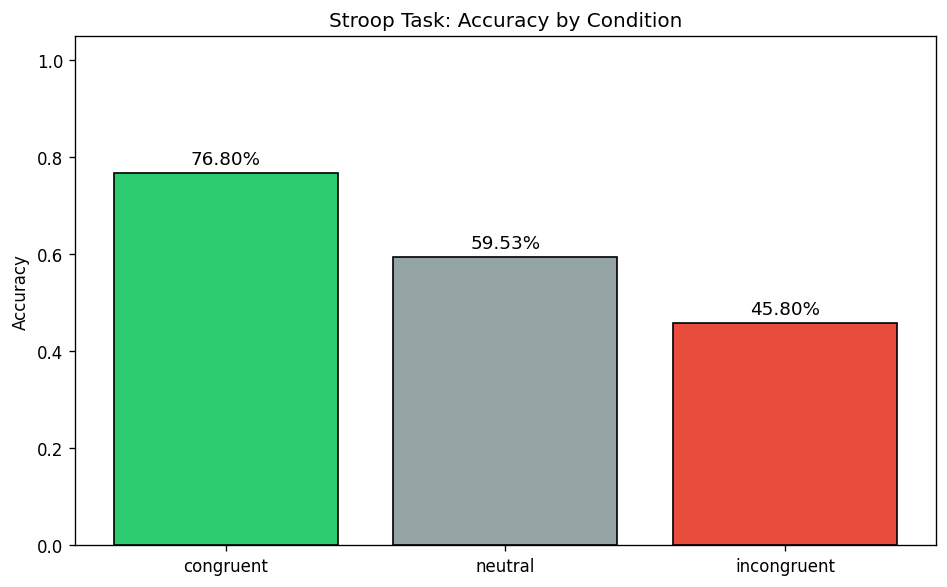

In [6]:
fig = plot_accuracy(summary)
plt.show()

### 2b. Response Conflict by Condition

Response conflict is operationalized as the inverse of the activation gap
between the two highest responses. Higher conflict indicates more competition
and serves as a proxy for slower reaction times.

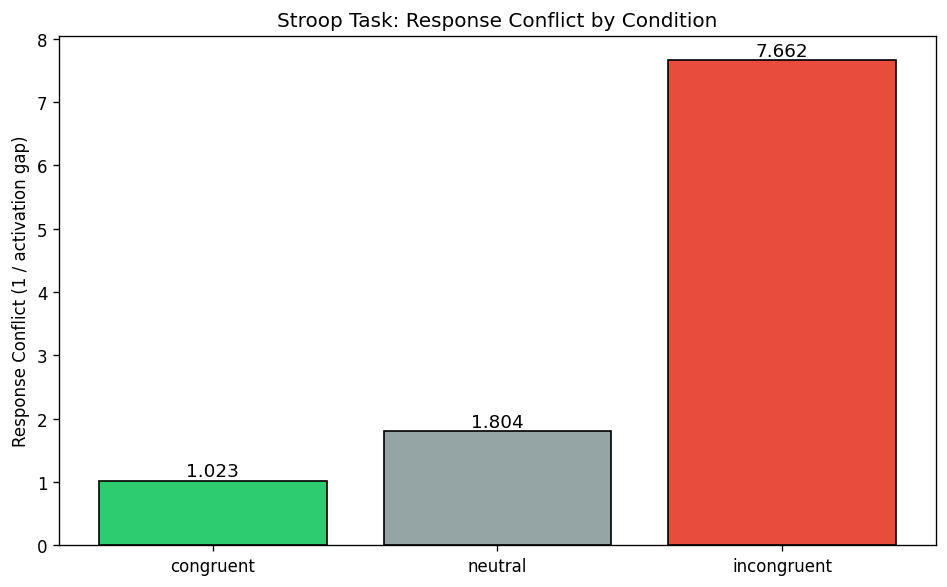

In [7]:
fig = plot_conflict(summary)
plt.show()

## 3. Parameter Exploration: Cognitive Control Strength (W_top)

We vary W_top from 0.1 to 0.7 while holding W_bottom at 1.0.

This models different levels of cognitive control:
- **Low W_top (0.1):** weak control, e.g., a fatigued or distracted participant
- **High W_top (0.7):** strong control, e.g., a focused, well-practiced participant

**Prediction:** As W_top increases, the Stroop effect (interference) should shrink
because the controlled pathway becomes strong enough to override automatic word reading.

In [8]:
w_top_values = [0.1, 0.3, 0.5, 0.7]
wtop_configs = {}

print(f"{'W_top':>6s}  {'Cong Acc':>10s}  {'Neut Acc':>10s}  {'Incong Acc':>10s}  {'Interference':>13s}")
print("-" * 60)

for wt in w_top_values:
    res = run_experiment(w_top=wt, n_runs=30, seed=42)
    s = summarize_results(res)
    wtop_configs[f"w_top={wt}"] = s
    print(f"{wt:>6.1f}  {s['congruent']['accuracy']:>9.2%}  "
          f"{s['neutral']['accuracy']:>9.2%}  "
          f"{s['incongruent']['accuracy']:>9.2%}  "
          f"{s['interference']:>12.2%}")

 W_top    Cong Acc    Neut Acc  Incong Acc   Interference
------------------------------------------------------------
   0.1     68.67%     49.87%     35.47%        14.40%
   0.3     79.40%     57.27%     49.20%         8.07%
   0.5     82.67%     71.07%     55.53%        15.53%
   0.7     88.27%     76.93%     69.53%         7.40%


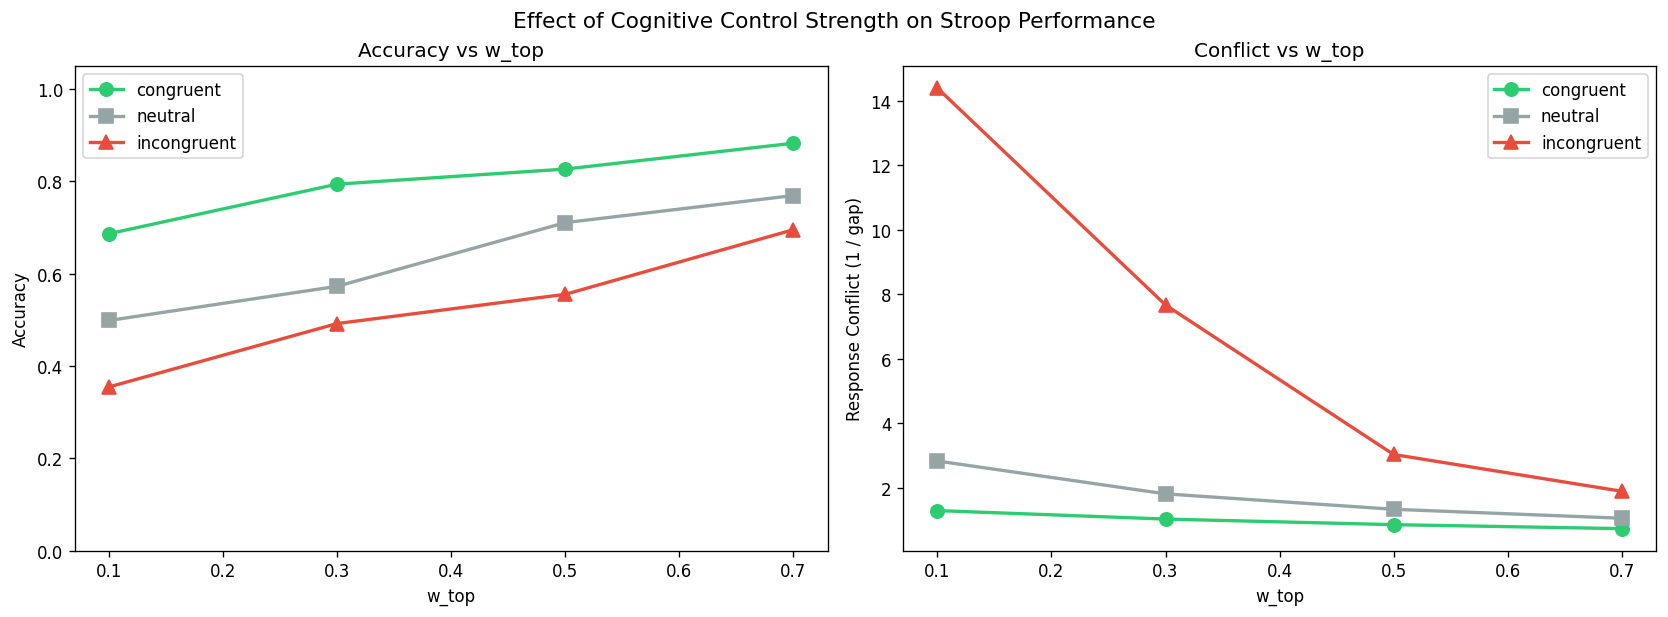

In [9]:
fig = plot_parameter_effect(wtop_configs, "w_top", w_top_values)
fig.suptitle("Effect of Cognitive Control Strength on Stroop Performance", 
             fontsize=13, y=1.02)
plt.show()

**Left panel (accuracy):** All three conditions improve as W_top increases, confirming that stronger cognitive control (top-down/controlled processing) helps across the board. Critically, the incongruent line rises fastest—it benefits most because it is the condition where controlled processing is needed to override the automatic (wrong) word-reading response.

**Right panel (conflict):** Incongruent conflict drops steeply as W_top increases, while congruent and neutral remain flat and low. This shows that cognitive control specifically reduces the response competition that defines the Stroop effect, rather than changing the processing of non-conflicting trials.

## 4. Parameter Exploration: Ink Pathway Weight

We vary the ink pathway weight (0.4, 0.6, 0.8) while holding word weight at 1.0.

This controls the automaticity asymmetry — larger gaps between word and ink
weights should produce stronger Stroop effects.

In [10]:
ink_values = [0.4, 0.6, 0.8]
ink_configs = {}

print(f"{'Ink Wt':>7s}  {'Cong Acc':>10s}  {'Neut Acc':>10s}  {'Incong Acc':>10s}  {'Interference':>13s}")
print("-" * 62)

for iw in ink_values:
    res = run_experiment(word_weight=1.0, ink_weight=iw, n_runs=30, seed=42)
    s = summarize_results(res)
    ink_configs[f"ink_weight={iw}"] = s
    print(f"{iw:>7.1f}  {s['congruent']['accuracy']:>9.2%}  "
          f"{s['neutral']['accuracy']:>9.2%}  "
          f"{s['incongruent']['accuracy']:>9.2%}  "
          f"{s['interference']:>12.2%}")

 Ink Wt    Cong Acc    Neut Acc  Incong Acc   Interference
--------------------------------------------------------------
    0.4     76.53%     55.53%     43.53%        12.00%
    0.6     78.93%     60.53%     47.80%        12.73%
    0.8     76.40%     61.27%     50.60%        10.67%


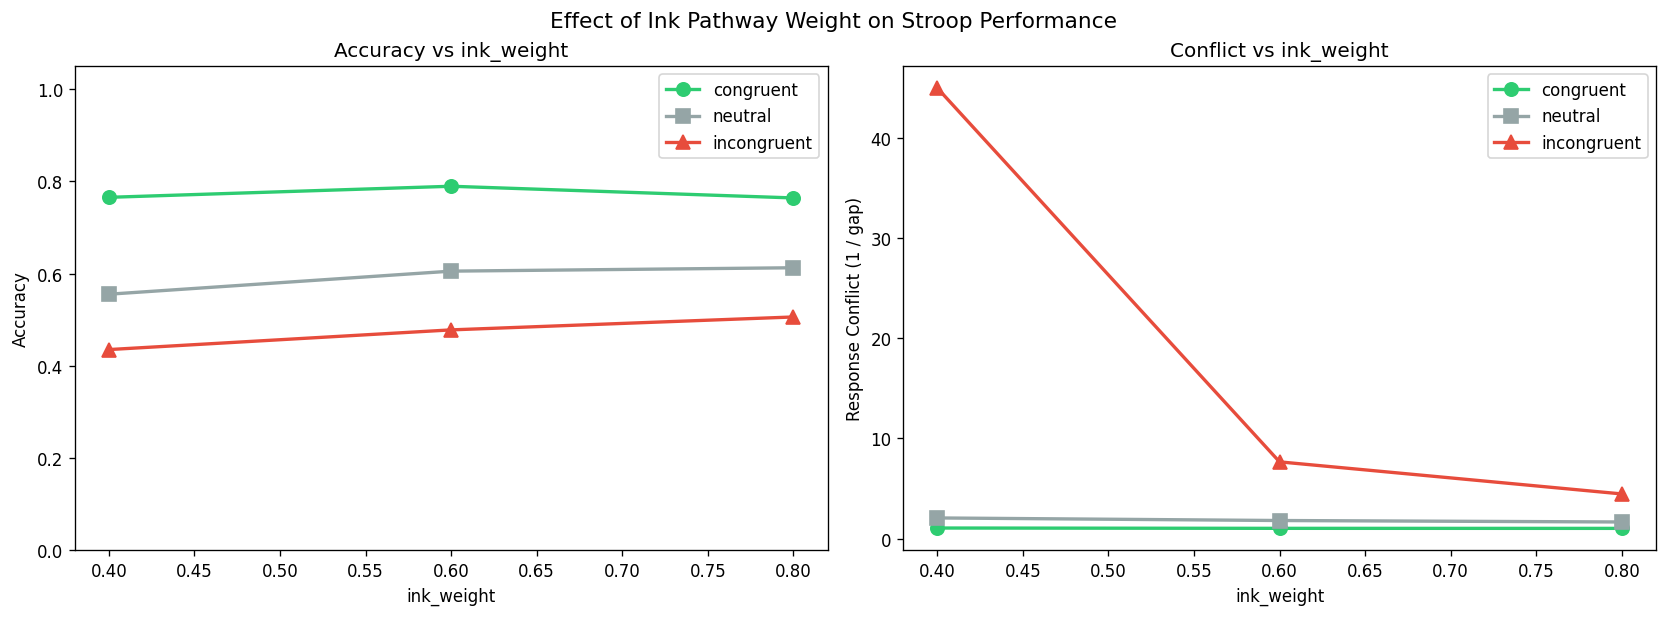

In [11]:
fig = plot_parameter_effect(ink_configs, "ink_weight", ink_values)
fig.suptitle("Effect of Ink Pathway Weight on Stroop Performance", 
             fontsize=13, y=1.02)
plt.show()

**Left panel (accuracy):** Increasing ink pathway weight mainly affects neutral and incongruent trials. Congruent accuracy stays flat because both pathways already agree — the dominant driver is word weight (1.0), so strengthening ink adds little. Neutral and incongruent both improve because ink is the only correct signal in those trials: neutral has no word contribution, and incongruent has a misleading word, so a stronger ink pathway gives the correct response more activation to compete with.

**Right panel (conflict):** Incongruent conflict drops sharply as ink weight increases. At ink_weight=0.4, the ink pathway is much weaker than the word pathway (0.4 vs 1.0), so the wrong response nearly matches the correct one — producing extreme competition. By ink_weight=0.8, the ink signal is strong enough that the correct response pulls clearly ahead, reducing conflict. Congruent and neutral remain low throughout since neither condition has two strong competing responses.

## 5. Parameter Exploration: Boltzmann Temperature

We vary the temperature parameter (0.1, 0.5, 1.0) which controls
response selection noise.

- **Low temperature (0.1):** nearly deterministic selection
- **High temperature (1.0):** noisier, more random selection

In [12]:
temp_values = [0.1, 0.3, 0.5, 0.8, 1.0]
temp_configs = {}

print(f"{'Temp':>6s}  {'Cong Acc':>10s}  {'Neut Acc':>10s}  {'Incong Acc':>10s}  {'Interference':>13s}")
print("-" * 60)

for t in temp_values:
    res = run_experiment(temperature=t, n_runs=30, seed=42)
    s = summarize_results(res)
    temp_configs[f"temperature={t}"] = s
    print(f"{t:>6.1f}  {s['congruent']['accuracy']:>9.2%}  "
          f"{s['neutral']['accuracy']:>9.2%}  "
          f"{s['incongruent']['accuracy']:>9.2%}  "
          f"{s['interference']:>12.2%}")

  Temp    Cong Acc    Neut Acc  Incong Acc   Interference
------------------------------------------------------------
   0.1    100.00%     99.40%     78.80%        20.60%
   0.3     92.40%     76.27%     53.53%        22.73%
   0.5     80.53%     59.93%     48.67%        11.27%
   0.8     62.20%     46.87%     40.73%         6.13%
   1.0     58.13%     47.33%     40.73%         6.60%


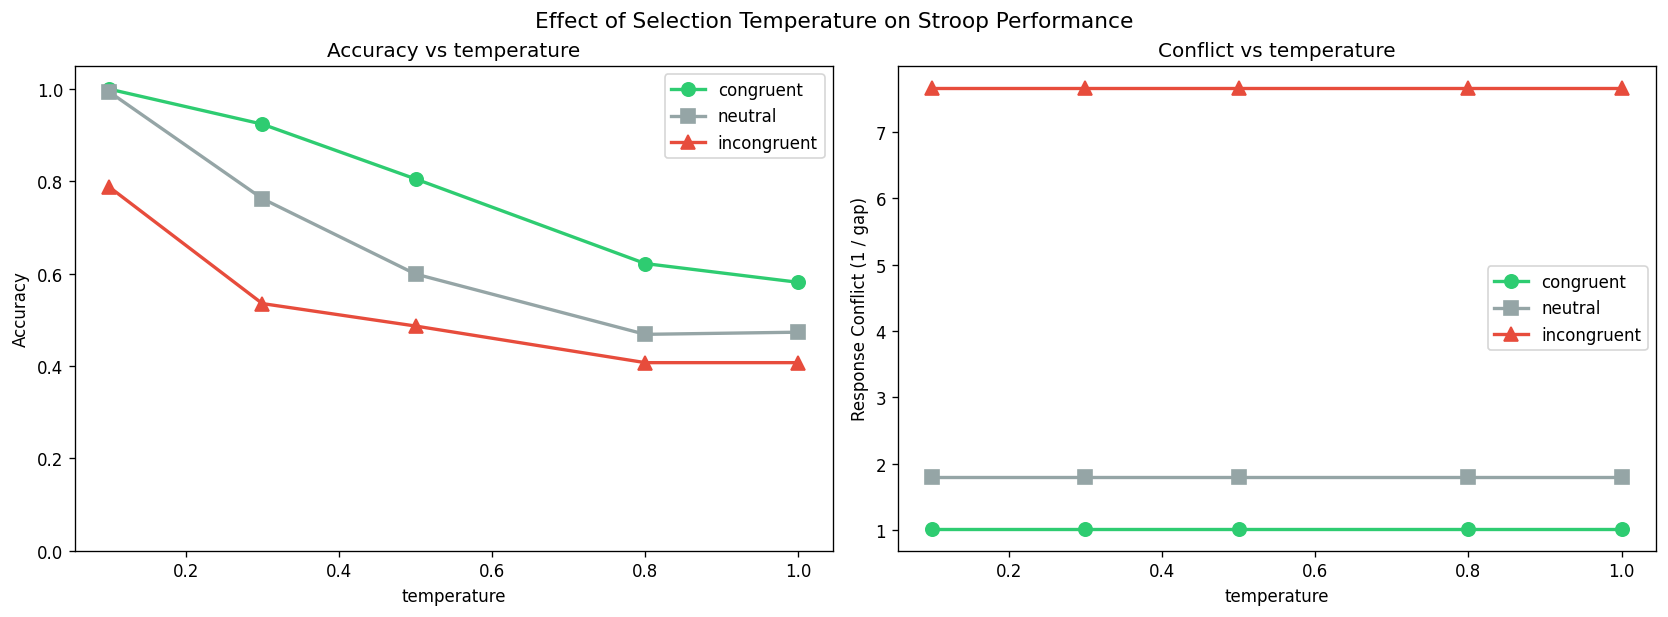

In [13]:
fig = plot_parameter_effect(temp_configs, "temperature", temp_values)
fig.suptitle("Effect of Selection Temperature on Stroop Performance", 
             fontsize=13, y=1.02)
plt.show()

**Left panel (accuracy):** All three conditions decline as temperature increases, because higher temperature makes Boltzmann selection noisier. The model is more likely to pick a suboptimal response even when one has clearly higher activation. At low temperature (0.1), selection is nearly deterministic and congruent accuracy approaches 100%. The ordering is preserved throughout: congruent > neutral > incongruent.

**Right panel (conflict):** Conflict is completely flat across all temperatures. This is expected; temperature only affects the *selection* stage, not the *activation* stage. The combined activations (and therefore the gap between the top two responses) are identical regardless of temperature. What changes is how often the model picks the wrong response despite knowing the right one, which is purely an accuracy effect.

## 6. Summary of Predictions

We check each prediction from the hypothesis against the simulation results.

In [ ]:
def check_prediction(name, condition, detail):
    symbol = "\u2705" if condition else "\u274c"
    print(f"{symbol} {name}")
    print(f"   {detail}\n")

print("=" * 60)
print("PREDICTION SUMMARY (default parameters)")
print("=" * 60 + "\n")

# Prediction 1: Accuracy ordering
check_prediction(
    "Congruent accuracy > Neutral accuracy",
    summary["congruent"]["accuracy"] > summary["neutral"]["accuracy"],
    f"{summary['congruent']['accuracy']:.2%} vs {summary['neutral']['accuracy']:.2%}"
)

check_prediction(
    "Neutral accuracy > Incongruent accuracy",
    summary["neutral"]["accuracy"] > summary["incongruent"]["accuracy"],
    f"{summary['neutral']['accuracy']:.2%} vs {summary['incongruent']['accuracy']:.2%}"
)

# Prediction 2: Conflict ordering
check_prediction(
    "Incongruent conflict > Neutral conflict",
    summary["incongruent"]["mean_conflict"] > summary["neutral"]["mean_conflict"],
    f"{summary['incongruent']['mean_conflict']:.2f} vs {summary['neutral']['mean_conflict']:.2f}"
)

check_prediction(
    "Neutral conflict > Congruent conflict",
    summary["neutral"]["mean_conflict"] > summary["congruent"]["mean_conflict"],
    f"{summary['neutral']['mean_conflict']:.2f} vs {summary['congruent']['mean_conflict']:.2f}"
)

# Prediction 3: Interference > Facilitation (conflict measure)
check_prediction(
    "Interference > Facilitation (conflict measure)",
    summary["conflict_interference"] > summary["conflict_facilitation"],
    f"Interference={summary['conflict_interference']:.2f}, "
    f"Facilitation={summary['conflict_facilitation']:.2f}"
)

# Prediction 4: Stroop effect shrinks with increasing W_top
low_control = wtop_configs["w_top=0.1"]["interference"]
high_control = wtop_configs["w_top=0.7"]["interference"]
check_prediction(
    "Stroop effect shrinks with increasing cognitive control (W_top)",
    low_control > high_control,
    f"Interference at W_top=0.1: {low_control:.2%}, at W_top=0.7: {high_control:.2%}"
)

PREDICTION SUMMARY (default parameters)

✅ Congruent accuracy > Neutral accuracy
   76.80% vs 59.53%

✅ Neutral accuracy > Incongruent accuracy
   59.53% vs 45.80%

✅ Incongruent conflict > Neutral conflict
   7.66 vs 1.80

✅ Neutral conflict > Congruent conflict
   1.80 vs 1.02

✅ Interference > Facilitation (conflict measure)
   Interference=5.86, Facilitation=0.78

✅ Stroop effect shrinks with increasing cognitive control (W_top)
   Interference at W_top=0.1: 14.40%, at W_top=0.7: 7.40%



## 7. Detailed Trial-Level Data

For reference, here is a sample of raw trial-level data from the main experiment.

In [15]:
df = pd.DataFrame(results)

# Show a few trials of each type
display_cols = ["trial_type", "ink_color", "word_content", 
                "correct_response", "selected_response", 
                "is_correct", "activation_gap", "response_conflict"]

sample = pd.concat([
    df[df["trial_type"] == "congruent"].head(3),
    df[df["trial_type"] == "neutral"].head(3),
    df[df["trial_type"] == "incongruent"].head(3),
])

sample[display_cols].reset_index(drop=True)

,trial_type,ink_color,word_content,correct_response,selected_response,is_correct,activation_gap,response_conflict
0,congruent,red,red,say_red,say_blue,False,0.977966,1.022530
1,congruent,green,green,say_green,say_green,True,0.977966,1.022530
2,congruent,blue,blue,say_blue,say_blue,True,0.977966,1.022530
3,neutral,green,neutral,say_green,say_green,True,0.554237,1.804281
4,neutral,red,neutral,say_red,say_blue,False,0.554237,1.804281
5,neutral,green,neutral,say_green,say_green,True,0.554237,1.804281
6,incongruent,green,red,say_green,say_blue,False,0.130508,7.662338
7,incongruent,blue,red,say_blue,say_red,False,0.130508,7.662338
8,incongruent,blue,red,say_blue,say_blue,True,0.130508,7.662338
